In [18]:
import numpy as np

In [60]:
emb = np.load("/media/ubuntu/sda/first_hospital/label.npy")
data = np.load("/media/ubuntu/sda/first_hospital/data.npy")

In [66]:
import pickle 
with open("/media/ubuntu/sda/first_hospital/sample_info.pkl", 'rb')as f:
    a = pickle.load(f)

In [70]:
len(a)

176648

In [72]:
1 in a[1]['label']

False

In [75]:
b = 0
for i in range(len(a)):
    if 1 in a[i]['label']:
        b += 1

In [76]:
b

14869

In [77]:
14869 / len(a)

0.08417304469906255

In [61]:
emb.shape

(176648, 15)

In [62]:
emb.sum()

np.int64(70743)

<Axes: >

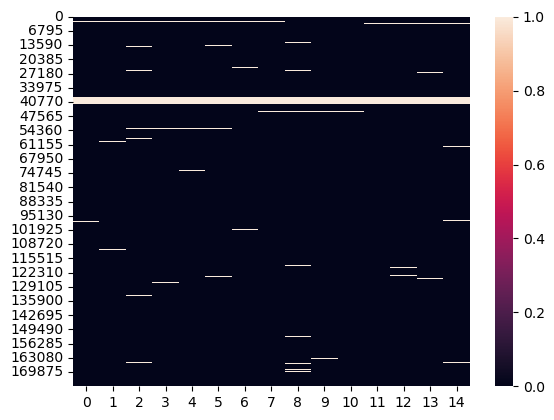

In [65]:
import seaborn as sns
sns.heatmap(emb)

In [30]:
emb.sum()

np.int64(1474)

In [24]:
emb.shape

emb_flat = emb.reshape(-1, 2048)
n_points = emb_flat.shape[0]
patient_idx = np.arange(n_points) // 200
names_a = np.asarray(names)
labels_a = np.asarray(labels)
name_per_point = names_a.ravel() if names_a.ndim > 1 else names_a[patient_idx]
label_per_point = labels_a.ravel() if labels_a.ndim > 1 else labels_a[patient_idx]

In [ ]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

pca = PCA(n_components=40)
emb_20 = pca.fit_transform(emb_flat)

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(emb_20)

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 30528 (\N{CJK UNIFIED IDEOGRAPH-7740}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 20110 (\N{CJK UNIFIED IDEOGRAPH-4E8E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 28085 (\N{CJK UNIFIED IDEOGRAPH-6DB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_737705/3283176898.py:23: UserWarning: Glyph 21608 (\N{CJK UNIFIED I

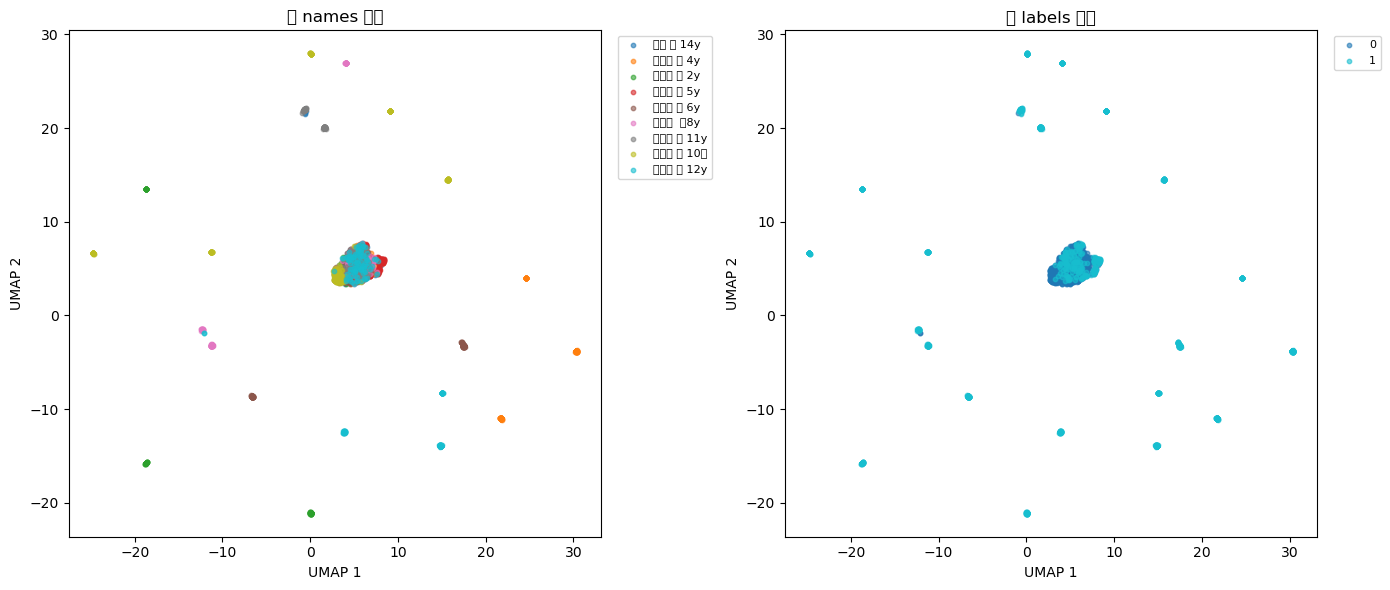

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

uniq_names = np.unique(name_per_point)
cmap_names = plt.cm.tab10(np.linspace(0, 1, len(uniq_names)))
for i, nm in enumerate(uniq_names):
    mask = (name_per_point == nm).ravel()
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[cmap_names[i]], label=str(nm), alpha=0.6, s=10)
axes[0].set_title("按 names 着色")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

uniq_labels = np.unique(label_per_point)
cmap_labels = plt.cm.tab10(np.linspace(0, 1, len(uniq_labels)))
for i, lb in enumerate(uniq_labels):
    mask = (label_per_point == lb).ravel()
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[cmap_labels[i]], label=str(lb), alpha=0.6, s=10)
axes[1].set_title("按 labels 着色")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()